In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import sys
import os

- Spot Price ($S_0$): Last closing price of the front-month futures contract (CL=F).
- Spot Volatility ($\sigma_1$): Annualized standard deviation of the asset's daily log returns.
- Initial Yield ($\delta_0$): Current market premium for holding physical oil, from smoothed data.
- Yield Volatility ($\sigma_2$): Annualized standard deviation of the yield's regression residuals.
- Mean Reversion ($\kappa$): Speed at which the convenience yield returns to its long-term baseline.
- Long-Term Mean ($\alpha$): The equilibrium level of the convenience yield during stable supply. 
- Correlation ($\rho$): Correlation between daily spot price returns and convenience yield changes.

## 1. Fetching Data

In [2]:
# 1. Download WTI Crude Oil Futures (Last 5 Years to capture 2020 volatility)
print("Fetching WTI Data...")
wti_data = yf.download("CL=F", period="5y", interval="1d")
wti_prices = wti_data['Close'].dropna()

# 2. Download Risk-Free Rate (13-week T-Bill)
print("Fetching Interest Rate Data...")
rf_data = yf.download("^IRX", period="5y", interval="1d")
# The T-bill yield is quoted in percent (e.g., 5.0 means 5%), so we divide by 100
rf_rates = (rf_data['Close'] / 100).dropna()

# Align the datasets by date
df = pd.concat([wti_prices, rf_rates], axis=1, join='inner')
df.columns = ['WTI_Spot', 'RiskFree_Rate']

print(df.tail())

Fetching WTI Data...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Fetching Interest Rate Data...
             WTI_Spot  RiskFree_Rate
Date                                
2026-02-19  66.430000        0.03595
2026-02-20  66.389999        0.03595
2026-02-23  66.309998        0.03588
2026-02-24  65.629997        0.03588
2026-02-25  65.419998        0.03588


## 2. Volaility and convenience yield
### 2.1 Spot Volatility ($\sigma_1$)

In [3]:
# Assume 252 trading days in a year
dt = 1 / 252 

# Calculate daily log returns of WTI
df['Log_Returns'] = np.log(df['WTI_Spot'] / df['WTI_Spot'].shift(1))

# 1. Extract Initial Spot Price (S0)
S0 = df['WTI_Spot'].iloc[-1]

# 2. Extract Spot Volatility (sigma_1)
sigma_1 = df['Log_Returns'].std() * np.sqrt(252)

# # 3. Imply the Historical Convenience Yield
# # We use the drift of the spot price to reverse-engineer a proxy for delta
# # drift = (r - delta) * dt  =>  delta = r - (drift / dt)
# df['Proxy_Yield_1'] = df['RiskFree_Rate'] - (df['Log_Returns'] / dt)

# # Smooth the noisy daily yield proxy using a 30-day moving average 
# df['Smoothed_Yield_1'] = df['Proxy_Yield_1'].rolling(window=30).mean()


df = df.dropna()


print(f"Initial Spot Price (S0): {S0:.2f}")
print(f"Spot Volatility (sigma_1): {sigma_1:.1%}")
print(df.tail())

Initial Spot Price (S0): 65.42
Spot Volatility (sigma_1): 36.5%
             WTI_Spot  RiskFree_Rate  Log_Returns
Date                                             
2026-02-19  66.430000        0.03595     0.018843
2026-02-20  66.389999        0.03595    -0.000602
2026-02-23  66.309998        0.03588    -0.001206
2026-02-24  65.629997        0.03588    -0.010308
2026-02-25  65.419998        0.03588    -0.003205


## 2.2 Convenience yield ($\delta$)
We try to use the log return to get the convenience yield before, but due to the volatility of the return, we ge quite unrealistic convenience yield, which is above 100%. So, we are considering using the monthly return (21 truding days) to calculate the convenience yield.

In [4]:
# Calculate the rolling 21-day (1 month) return to stabilize the yield
df['Monthly_Return'] = df['WTI_Spot'].pct_change(21)

# Imply Convenience Yield (delta) from the monthly basis
# delta = r - (1/T) * ln(F/S)
# In a research sandbox, we use the return as a proxy for the curve slope
df['Proxy_Yield'] = df['RiskFree_Rate'] - (df['Monthly_Return'] * 12)

# Smooth with a larger window to capture the physical cycle
df['Smoothed_Yield'] = df['Proxy_Yield'].rolling(window=60).mean()
df = df.dropna()

# Final Extraction
delta_0 = df['Smoothed_Yield'].iloc[-1]

print(f"Realistic Initial Yield (delta_0): {delta_0:.2%}")

Realistic Initial Yield (delta_0): -30.07%


## 3. Run regression for the OU process
The Ou porecess:
$$d\delta_t = \kappa(\alpha - \delta_t)dt + \sigma dW_t$$
And the Euler discretization

$$\delta_{t} - \delta_{t-1} = \kappa(\alpha - \delta_{t-1})\Delta t + \epsilon$$
$$\delta_t - \delta_{t-1} = \kappa \alpha \Delta t - \kappa \delta_{t-1} \Delta t + \epsilon$$

In [5]:
# Prepare data for regression: y = beta_0 + beta_1 * x
Y = df['Smoothed_Yield'].diff().dropna()
X = df['Smoothed_Yield'].shift(1).dropna()

# Add constant for the intercept (beta_0)
X = sm.add_constant(X)

# Run Ordinary Least Squares (OLS) regression
model = sm.OLS(Y, X).fit()
beta_0 = model.params.iloc[0]  # Intercept
beta_1 = model.params.iloc[1]  # Slope
residuals = model.resid

# Map regression coefficients back to OU parameters
# beta_1 = -kappa * dt
kappa = -beta_1 / dt

# beta_0 = kappa * alpha * dt
alpha = beta_0 / (kappa * dt)

# Volatility of the yield (sigma_2) is the standard error of the residuals annualized
sigma_2 = residuals.std() / np.sqrt(dt)

# 4. Extract Correlation (rho)
rho = df['Log_Returns'].corr(df['Smoothed_Yield'].diff())

print(f"Mean Reversion Speed (kappa): {kappa:.4f}")
print(f"Long-Term Mean Yield (alpha): {alpha:.4f}")
print(f"Yield Volatility (sigma_2): {sigma_2:.4f}")
print(f"Correlation (rho): {rho:.4f}")

Mean Reversion Speed (kappa): 0.3444
Long-Term Mean Yield (alpha): 0.1277
Yield Volatility (sigma_2): 0.3932
Correlation (rho): -0.1691


## 4. Running simulations

In [6]:
# Update this path to where your 'gs_pricer.cpython...' file is located
sys.path.append(os.path.abspath("./build"))

import gs_pricer

In [7]:
# Create the parameters object
params = gs_pricer.GSParameters()

# Assign all variables from your data analysis
params.S0 = S0
params.sigma1 = sigma_1
params.delta0 = delta_0
params.sigma2 = sigma_2
params.kappa = kappa
params.alpha = alpha
params.rho = rho
params.r = df['RiskFree_Rate'].iloc[-1] 

print("--- Full Gibson-Schwartz Parameters Calibrated ---")
print(f"1. Spot Price (S0):            {params.S0:.2f}")
print(f"2. Spot Volatility (sigma1):   {params.sigma1:.2%}")
print(f"3. Initial Yield (delta0):     {params.delta0:.2%}")
print(f"4. Yield Volatility (sigma2):  {params.sigma2:.2%}")
print(f"5. Mean Reversion (kappa):     {params.kappa:.4f}")
print(f"6. Long-term Mean (alpha):     {params.alpha:.4f}")
print(f"7. Correlation (rho):          {params.rho:.4f}")
print(f"8. Risk-Free Rate (r):         {params.r:.2%}")
print("-" * 50)

--- Full Gibson-Schwartz Parameters Calibrated ---
1. Spot Price (S0):            65.42
2. Spot Volatility (sigma1):   36.49%
3. Initial Yield (delta0):     -30.07%
4. Yield Volatility (sigma2):  39.32%
5. Mean Reversion (kappa):     0.3444
6. Long-term Mean (alpha):     0.1277
7. Correlation (rho):          -0.1691
8. Risk-Free Rate (r):         3.59%
--------------------------------------------------


In [14]:
 # Settings: 100k paths, 252 steps (1 year), 1.0 year duration
num_paths = 100000
num_steps = 252
T = 1.0

engine = gs_pricer.MonteCarloEngine(params, num_paths, num_steps, T)

print(f"Running {num_paths} paths in C++...")
terminal_prices = engine.runSimulation() # This returns a Python list of prices

Running 100000 paths in C++...


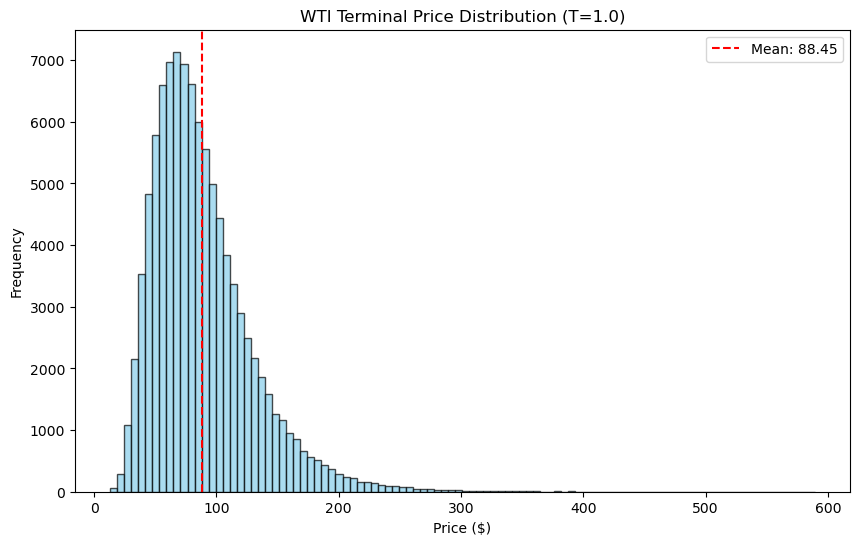

95% Prediction Range: [ 33.60630705 190.31598897]


In [16]:
# Convert to numpy for easier analysis
prices_array = np.array(terminal_prices)

plt.figure(figsize=(10, 6))
plt.hist(prices_array, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
plt.title(f"WTI Terminal Price Distribution (T={T})")
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.axvline(np.mean(prices_array), color='red', linestyle='dashed', label=f'Mean: {np.mean(prices_array):.2f}')
plt.legend()
plt.show()

print(f"95% Prediction Range: {np.percentile(prices_array, [2.5, 97.5])}")